# Isotropic vs Per-Dimension Variance: UncertainGen Comparison

Tests whether UncertainGen needs per-dimension variance (N, D) or whether a single
scalar variance per sample (N, 1) — isotropic, like PCL's kappa — is sufficient.

Models compared:
1. **NonLinear** (deterministic baseline) — point embeddings
2. **UG adaptive** (per-dim var, α=1.0) — original diagonal Gaussian
3. **UG identity** (per-dim var, α=0.1) — original diagonal Gaussian
4. **UG adaptive scalar** (isotropic var, α=1.0) — N(μ, σ²I)
5. **UG identity scalar** (isotropic var, α=0.1) — N(μ, σ²I)
6. **PCL** (vMF, single kappa) — for reference

The scalar variants use `scalar_variance=True`, which gives the variance network
a single output expanded to all D dimensions. Same loss, same eval — only the
network's capacity to express per-dimension uncertainty differs.

## Setup

In [24]:
import sys, os, csv, tempfile
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from embedders.nonlinear import NonLinearEmbedder, set_seed
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase
from embedders.pcl import PCLEmbedder
from embedders.base import EmbeddingResult
from datasets.paired_reads import PairedReadsDataset
from clustering.kmedoid import KMedoidClusterer
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
    compute_class_center_medium_similarity,
)
import sklearn.metrics

SEED = 26042024
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_TSV = '../../data/dnabert/eval/reference/clustering_0.tsv'
TRAIN_FRAC = 0.7
MODEL_DIR = '../../models/notebook'

METRIC = 'l2'
MIN_BIN_SIZE = 5
KMEDOID_METHOD = 'alternate'

# Phase 2 training hyperparameters (same as genome_experiment)
VAR_EPOCHS = 100
VAR_LR = 0.001
VAR_BATCH_SIZE = 256
NEG_SAMPLE_PER_POS = 20
MAX_READ_NUM = 0

print(f'Device: {DEVICE}')

Device: cuda


## Data Loading

In [25]:
csv.field_size_limit(min(sys.maxsize, 2**31 - 1))
with open(DATA_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    header = next(reader)
    all_rows = list(reader)

sequences = [r[0] for r in all_rows]
labels_str = [r[1] for r in all_rows]
unique_labels = sorted(set(labels_str))

rng = np.random.RandomState(SEED)
species_to_idx = defaultdict(list)
for i, lab in enumerate(labels_str):
    species_to_idx[lab].append(i)

train_idx, test_idx = [], []
for lab in unique_labels:
    idxs = np.array(species_to_idx[lab])
    rng.shuffle(idxs)
    split = int(len(idxs) * TRAIN_FRAC)
    train_idx.extend(idxs[:split].tolist())
    test_idx.extend(idxs[split:].tolist())

train_seqs = [sequences[i] for i in train_idx]
train_labels = [labels_str[i] for i in train_idx]
test_seqs = [sequences[i] for i in test_idx]
test_labels_str = [labels_str[i] for i in test_idx]

lab2id = {l: i for i, l in enumerate(unique_labels)}
train_labels_num = np.array([lab2id[l] for l in train_labels])
test_labels = np.array([lab2id[l] for l in test_labels_str])
n_species = len(unique_labels)

# Build contrastive pairs for training
train_by_species = defaultdict(list)
for seq, lab in zip(train_seqs, train_labels):
    train_by_species[lab].append(seq)

train_csv_path = os.path.join(tempfile.gettempdir(), 'genome_train_pairs.csv')
n_pairs = 0
with open(train_csv_path, 'w') as f:
    for lab in unique_labels:
        seqs = train_by_species[lab]
        for i in range(0, len(seqs) - 1, 2):
            f.write(f'{seqs[i]},{seqs[i + 1]}\n')
            n_pairs += 1

print(f'Total: {len(sequences)} sequences, {n_species} species')
print(f'Train: {len(train_seqs)}, Test: {len(test_seqs)}, Pairs: {n_pairs}')

Total: 20000 sequences, 200 species
Train: 14000, Test: 6000, Pairs: 7000


## Load Pre-trained Baselines

In [26]:
set_seed(SEED)

# NonLinear (deterministic baseline)
model_nl = NonLinearEmbedder.load(os.path.join(MODEL_DIR, 'nonlinear.model'), device=DEVICE)
print('NonLinear loaded')

# UG adaptive per-dim (alpha=1.0)
model_ug_ad = UncertainGenEmbedder.load(
    os.path.join(MODEL_DIR, 'uncertaingen_adaptive.model'), device=DEVICE)
print(f'UG adaptive (per-dim) loaded (k_form={model_ug_ad._k_form}, alpha={model_ug_ad._alpha})')

# UG identity per-dim (alpha=0.1)
model_ug_id = UncertainGenEmbedder.load(
    os.path.join(MODEL_DIR, 'uncertaingen_identity.model'), device=DEVICE)
print(f'UG identity (per-dim) loaded (k_form={model_ug_id._k_form}, alpha={model_ug_id._alpha})')

# PCL (for reference)
PCL_PATH = os.path.join(MODEL_DIR, 'pcl.model')
if os.path.exists(PCL_PATH):
    model_pcl = PCLEmbedder.load(PCL_PATH, device=DEVICE)
    print(f'PCL loaded')
else:
    model_pcl = None
    print('PCL model not found, skipping')

NonLinear loaded
UG adaptive (per-dim) loaded (k_form=adaptive, alpha=1.0)
UG identity (per-dim) loaded (k_form=identity, alpha=1.0)
PCL loaded


## Train / Load Scalar Variance Models

Same Phase 1 mean network (copied from NonLinear), only Phase 2 differs:
the variance network outputs a **single scalar** per sample instead of D values.

In [27]:
def train_or_load_scalar_ug(k_form, alpha, save_name):
    """Train or load a scalar-variance UG model."""
    path = os.path.join(MODEL_DIR, save_name)
    losses_path = path.replace('.model', '_losses.npy')

    if os.path.exists(path):
        model = UncertainGenEmbedder.load(path, device=DEVICE)
        losses = np.load(losses_path) if os.path.exists(losses_path) else None
        print(f'Loaded {save_name} (scalar_variance={model._scalar_variance})')
        return model, losses

    print(f'Training {save_name} (k_form={k_form}, alpha={alpha}, scalar_variance=True)...')
    model = UncertainGenEmbedder(
        k=4, dim=256, alpha=alpha, k_form=k_form,
        device=DEVICE, seed=SEED, scalar_variance=True,
    )
    model.copy_mean_from(model_nl)
    print('  Copied mean network from NonLinear')

    # Build dataset for Phase 2
    # Cap max_read_num to available pairs (0 = use all)
    effective_max = min(MAX_READ_NUM, n_pairs) if MAX_READ_NUM > 0 else 0
    dataset = PairedReadsDataset(
        file_path=train_csv_path,
        transform_func=model._feature_extractor.extract,
        neg_sample_per_pos=NEG_SAMPLE_PER_POS,
        max_read_num=effective_max, seed=SEED,
    )

    losses = train_variance_phase(
        model, dataset, lr=VAR_LR, epochs=VAR_EPOCHS,
        device=DEVICE, batch_size=VAR_BATCH_SIZE,
        alpha=alpha, verbose=True,
    )

    model.save(path)
    np.save(losses_path, np.array(losses))
    print(f'  Saved to {path}, final loss: {losses[-1]:.4f}')
    return model, np.array(losses)


# Scalar UG adaptive (alpha=1.0)
model_ug_ad_s, losses_ad_s = train_or_load_scalar_ug(
    k_form='adaptive', alpha=1.0, save_name='ug_scalar_adaptive.model')

# Scalar UG identity (alpha=1)
model_ug_id_s, losses_id_s = train_or_load_scalar_ug(
    k_form='identity', alpha=1, save_name='ug_scalar_identity.1.model')

Loaded ug_scalar_adaptive.model (scalar_variance=True)
Training ug_scalar_identity.1.model (k_form=identity, alpha=1, scalar_variance=True)...
  Copied mean network from NonLinear


 Counting lines │██████████████████████████████│ 140M/140M [00:00<00:00]
 Loading read pairs │██████████████████████████████│ 7000/7000 [00:44<00:00]


Dataset loaded: 7000 read pairs from 7000 total lines.


 Phase 2 (variance) │██████████████████████████████│ 100/100 [01:38<00:00, loss=0.077234]


  Saved to ../models/notebook\ug_scalar_identity.1.model, final loss: 0.0772


## Training Loss Comparison

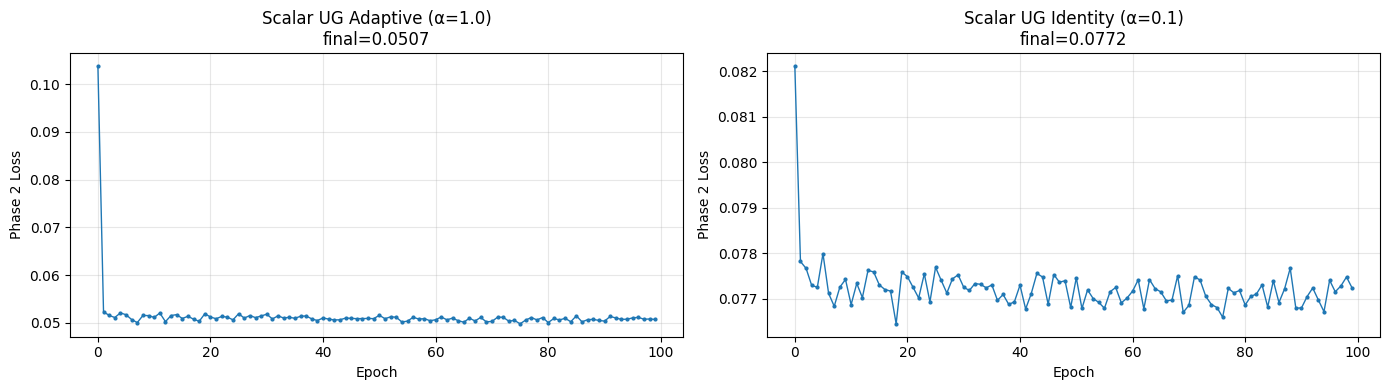

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, losses, title in [
    (axes[0], losses_ad_s, 'Scalar UG Adaptive (α=1.0)'),
    (axes[1], losses_id_s, 'Scalar UG Identity (α=0.1)'),
]:
    if losses is not None:
        ax.plot(losses, 'o-', markersize=2, linewidth=1)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Phase 2 Loss')
        ax.set_title(f'{title}\nfinal={losses[-1]:.4f}')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title}\n(no loss data)')

plt.tight_layout()
plt.show()

## Embed Train + Test

In [29]:
# NonLinear
train_emb_nl = model_nl.embed(train_seqs)
test_emb_nl = model_nl.embed(test_seqs)

# UG adaptive per-dim
train_emb_ug_ad = model_ug_ad.embed(train_seqs)
test_emb_ug_ad = model_ug_ad.embed(test_seqs)

# UG identity per-dim
train_emb_ug_id = model_ug_id.embed(train_seqs)
test_emb_ug_id = model_ug_id.embed(test_seqs)

# UG adaptive scalar
train_emb_ug_ad_s = model_ug_ad_s.embed(train_seqs)
test_emb_ug_ad_s = model_ug_ad_s.embed(test_seqs)

# UG identity scalar
train_emb_ug_id_s = model_ug_id_s.embed(train_seqs)
test_emb_ug_id_s = model_ug_id_s.embed(test_seqs)

# PCL
if model_pcl is not None:
    train_emb_pcl = model_pcl.embed(train_seqs)
    test_emb_pcl = model_pcl.embed(test_seqs)

# Verify scalar variance is isotropic
v = test_emb_ug_ad_s.variance
print(f'Scalar adaptive: var shape {v.shape}, '
      f'all dims equal per sample: {np.allclose(v, v[:, :1])}')
print(f'  var range: [{v.mean(axis=1).min():.6f}, {v.mean(axis=1).max():.6f}]')

v2 = test_emb_ug_id_s.variance
print(f'Scalar identity: var shape {v2.shape}, '
      f'all dims equal per sample: {np.allclose(v2, v2[:, :1])}')
print(f'  var range: [{v2.mean(axis=1).min():.6f}, {v2.mean(axis=1).max():.6f}]')

# Per-dim originals for reference
print(f'\nPer-dim adaptive: var range [{test_emb_ug_ad.variance.mean(axis=1).min():.6f}, '
      f'{test_emb_ug_ad.variance.mean(axis=1).max():.6f}]')
print(f'Per-dim identity: var range [{test_emb_ug_id.variance.mean(axis=1).min():.6f}, '
      f'{test_emb_ug_id.variance.mean(axis=1).max():.6f}]')

Scalar adaptive: var shape (6000, 256), all dims equal per sample: True
  var range: [0.071749, 0.189030]
Scalar identity: var shape (6000, 256), all dims equal per sample: True
  var range: [0.000333, 0.009092]

Per-dim adaptive: var range [0.479855, 1.046962]
Per-dim identity: var range [0.000363, 0.005770]


## Clustering Evaluation

In [30]:
def evaluate_model(name, train_emb, test_emb, k_form=None, alpha=1.0,
                   use_variance=False, use_kappa=False):
    """Run clustering evaluation and return results dict."""
    kwargs = {}
    if use_variance:
        kwargs['variances'] = train_emb.variance
        kwargs['k_form'] = k_form
        kwargs['alpha'] = alpha
    if use_kappa:
        kwargs['kappas'] = train_emb.kappa
        kwargs['k_form'] = k_form
        kwargs['alpha'] = alpha

    pv, sc = compute_class_center_medium_similarity(
        train_emb.point_estimate, train_labels_num, metric=METRIC, **kwargs)
    threshold = pv[-3]

    kmed_kwargs = {'metric': METRIC, 'min_bin_size': MIN_BIN_SIZE,
                   'scale': sc, 'method': KMEDOID_METHOD}
    if k_form:
        kmed_kwargs['k_form'] = k_form
        kmed_kwargs['alpha'] = alpha
    kmed = KMedoidClusterer(**kmed_kwargs)
    pred = kmed.fit_predict(test_emb, min_similarity=threshold)

    r = count_high_quality_clusters(test_labels, pred)
    k = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    coverage = assigned / len(test_labels)

    print(f'{name:>30s}  k={k:3d}  assigned={assigned}/{len(test_labels)} ({coverage:.1%})  '
          f'F1>0.3={r["counts"][2]:3d}  F1>0.5={r["counts"][4]:3d}  '
          f'F1>0.7={r["counts"][6]:3d}  F1>0.9={r["counts"][8]:3d}')

    return {'name': name, 'pred': pred, 'r': r, 'k': k,
            'assigned': assigned, 'coverage': coverage}


results = {}

# NonLinear baseline
results['NonLinear'] = evaluate_model(
    'NonLinear (det)', train_emb_nl, test_emb_nl)

print('--- Per-dimension variance ---')
results['UG adaptive'] = evaluate_model(
    'UG adaptive (per-dim)', train_emb_ug_ad, test_emb_ug_ad,
    k_form='adaptive', alpha=1.0, use_variance=True)
results['UG identity'] = evaluate_model(
    'UG identity (per-dim)', train_emb_ug_id, test_emb_ug_id,
    k_form='identity', alpha=0.1, use_variance=True)

print('--- Scalar (isotropic) variance ---')
results['UG adaptive scalar'] = evaluate_model(
    'UG adaptive (scalar)', train_emb_ug_ad_s, test_emb_ug_ad_s,
    k_form='adaptive', alpha=1.0, use_variance=True)
results['UG identity scalar'] = evaluate_model(
    'UG identity (scalar)', train_emb_ug_id_s, test_emb_ug_id_s,
    k_form='identity', alpha=0.1, use_variance=True)

if model_pcl is not None:
    print('--- PCL (vMF) ---')
    results['PCL cosine'] = evaluate_model(
        'PCL cosine', train_emb_pcl, test_emb_pcl,
        k_form='cosine', alpha=1.0, use_kappa=True)

Auto-calibrated scale: 2.997387 (median raw distance: 0.2313)
Percentile values: [0.12450093482649371, 0.2280380439922255, 0.3230909830239522, 0.41105853727277486, 0.5000850313731194, 0.5835276401654267, 0.6581730939166871, 0.73087140859097, 0.8041553183219755]
KMedoids: k_est=123, n=6000, method=alternate
               NonLinear (det)  k=121  assigned=5993/6000 (99.9%)  F1>0.3= 68  F1>0.5= 40  F1>0.7= 18  F1>0.9=  8
--- Per-dimension variance ---
Auto-calibrated scale: 3.760325 (median raw distance: 0.1843)
Percentile values: [0.1205882877111435, 0.2248486876487732, 0.321975439786911, 0.40913355350494385, 0.5000032186508179, 0.5822020769119263, 0.6587317585945129, 0.732488751411438, 0.8065897822380066]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:37<00:00]


KMedoids: k_est=125, n=6000, method=alternate
         UG adaptive (per-dim)  k=124  assigned=5996/6000 (99.9%)  F1>0.3= 64  F1>0.5= 39  F1>0.7= 18  F1>0.9=  7
Auto-calibrated scale: 0.120817 (median raw distance: 5.7372)
Percentile values: [0.257020503282547, 0.2977757453918457, 0.34630581736564636, 0.4236152172088623, 0.5000191330909729, 0.5695558190345764, 0.6293106079101562, 0.6822090744972229, 0.7326842546463013]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:23<00:00]


KMedoids: k_est=42, n=6000, method=alternate
         UG identity (per-dim)  k= 42  assigned=6000/6000 (100.0%)  F1>0.3= 15  F1>0.5=  3  F1>0.7=  3  F1>0.9=  2
--- Scalar (isotropic) variance ---
Auto-calibrated scale: 3.594094 (median raw distance: 0.1929)
Percentile values: [0.12489094585180283, 0.22768321633338928, 0.32347962260246277, 0.41103753447532654, 0.5000176429748535, 0.583310604095459, 0.6571233868598938, 0.7294041514396667, 0.8028985261917114]


...

KMedoids: k_est=126, n=6000, method=alternate
          UG adaptive (scalar)  k=124  assigned=5992/6000 (99.9%)  F1>0.3= 67  F1>0.5= 36  F1>0.7= 16  F1>0.9=  6
Auto-calibrated scale: 0.126535 (median raw distance: 5.4779)
Percentile values: [0.24026627838611603, 0.2835271954536438, 0.336500346660614, 0.4269421100616455, 0.5000483989715576, 0.5687503218650818, 0.6207019686698914, 0.6682694554328918, 0.716810941696167]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:22<00:00]


KMedoids: k_est=57, n=6000, method=alternate
          UG identity (scalar)  k= 56  assigned=5996/6000 (99.9%)  F1>0.3= 23  F1>0.5=  5  F1>0.7=  2  F1>0.9=  2
--- PCL (vMF) ---
Auto-calibrated scale: 5.756987 (median raw distance: 0.1204)
Percentile values: [0.19109167158603668, 0.26543834805488586, 0.34179219603538513, 0.42219632863998413, 0.500011682510376, 0.5640010833740234, 0.6225016117095947, 0.6753420233726501, 0.7361061573028564]


 Computing vMF similarity │██████████████████████████████│ 12/12 [00:00<00:00]


KMedoids: k_est=69, n=6000, method=alternate
                    PCL cosine  k= 69  assigned=6000/6000 (100.0%)  F1>0.3= 46  F1>0.5= 27  F1>0.7= 11  F1>0.9=  1


## Summary Table

In [31]:
print(f'{"Method":>30s}  {"k":>5s}  {"assigned":>8s}  {"cover":>6s}  '
      f'{"F1>0.3":>6s}  {"F1>0.5":>6s}  {"F1>0.7":>6s}  {"F1>0.9":>6s}')
print('-' * 95)

for key, s in results.items():
    r = s['r']
    print(f'{s["name"]:>30s}  {s["k"]:5d}  {s["assigned"]:8d}  {s["coverage"]:6.1%}  '
          f'{r["counts"][2]:6d}  {r["counts"][4]:6d}  {r["counts"][6]:6d}  {r["counts"][8]:6d}')

                        Method      k  assigned   cover  F1>0.3  F1>0.5  F1>0.7  F1>0.9
-----------------------------------------------------------------------------------------------
               NonLinear (det)    121      5993   99.9%      68      40      18       8
         UG adaptive (per-dim)    124      5996   99.9%      64      39      18       7
         UG identity (per-dim)     42      6000  100.0%      15       3       3       2
          UG adaptive (scalar)    124      5992   99.9%      67      36      16       6
          UG identity (scalar)     56      5996   99.9%      23       5       2       2
                    PCL cosine     69      6000  100.0%      46      27      11       1


## Bar Chart: Per-dim vs Scalar Variance

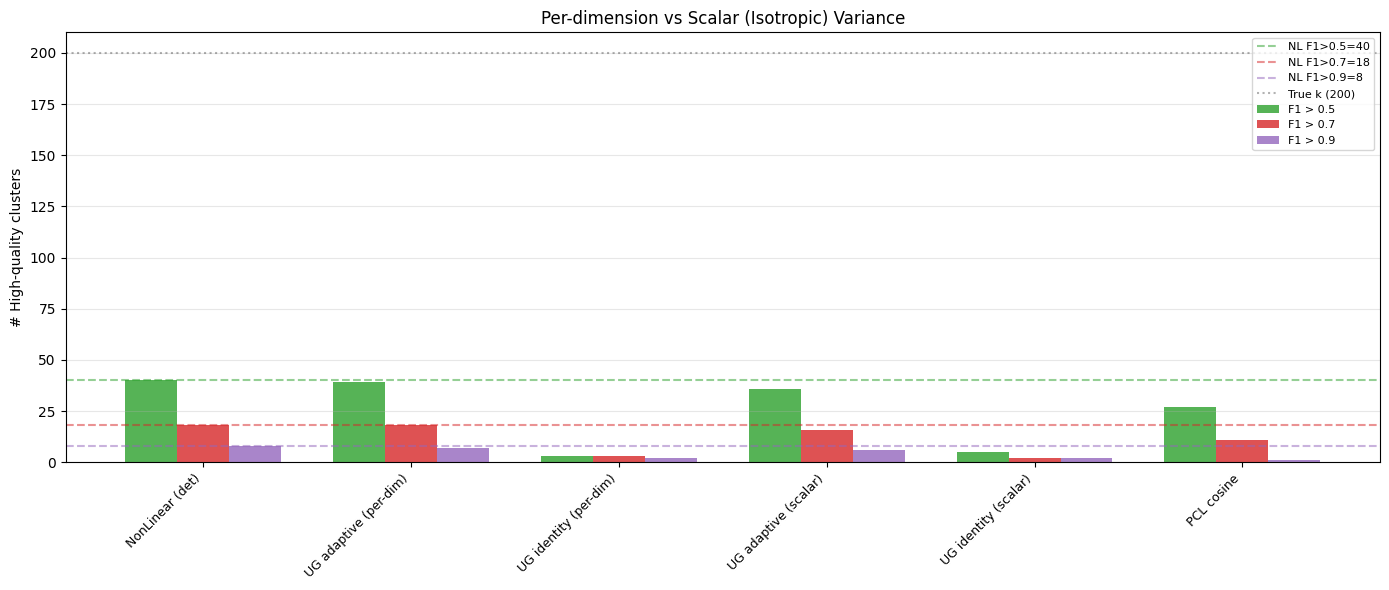

In [32]:
labels_list = list(results.keys())
f1_05 = [results[l]['r']['counts'][4] for l in labels_list]
f1_07 = [results[l]['r']['counts'][6] for l in labels_list]
f1_09 = [results[l]['r']['counts'][8] for l in labels_list]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(labels_list))
width = 0.25

bars1 = ax.bar(x - width, f1_05, width, label='F1 > 0.5', color='tab:green', alpha=0.8)
bars2 = ax.bar(x, f1_07, width, label='F1 > 0.7', color='tab:red', alpha=0.8)
bars3 = ax.bar(x + width, f1_09, width, label='F1 > 0.9', color='tab:purple', alpha=0.8)

# Baseline reference lines
nl_r = results['NonLinear']['r']
ax.axhline(nl_r['counts'][4], ls='--', color='tab:green', alpha=0.5,
           label=f'NL F1>0.5={nl_r["counts"][4]}')
ax.axhline(nl_r['counts'][6], ls='--', color='tab:red', alpha=0.5,
           label=f'NL F1>0.7={nl_r["counts"][6]}')
ax.axhline(nl_r['counts'][8], ls='--', color='tab:purple', alpha=0.5,
           label=f'NL F1>0.9={nl_r["counts"][8]}')
ax.axhline(n_species, ls=':', color='black', alpha=0.3, label=f'True k ({n_species})')

display_names = [results[l]['name'] for l in labels_list]
ax.set_xticks(x)
ax.set_xticklabels(display_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('# High-quality clusters')
ax.set_title('Per-dimension vs Scalar (Isotropic) Variance')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Selective Prediction

Use uncertainty as a rejection signal with the **NonLinear deterministic clustering** as base.
Compare per-dim variance (mean across dims) vs scalar variance (identical across dims).

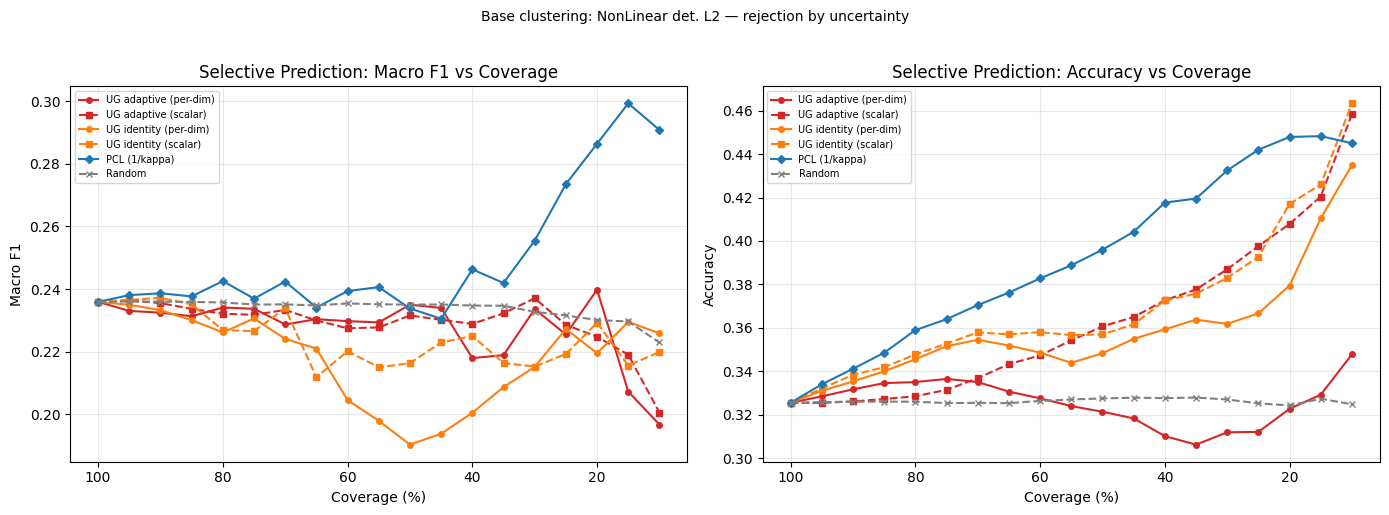

                           F1@100%  F1@80%  F1@60%  F1@40%  |  Acc@100%  Acc@80%  Acc@60%  Acc@40%
------------------------------------------------------------------------------------------
    UG adaptive (per-dim)   0.236   0.234   0.230   0.218  |   0.326   0.335   0.328   0.310
     UG adaptive (scalar)   0.236   0.232   0.227   0.229  |   0.326   0.329   0.347   0.373
    UG identity (per-dim)   0.236   0.226   0.204   0.200  |   0.326   0.346   0.349   0.359
     UG identity (scalar)   0.236   0.227   0.220   0.225  |   0.326   0.348   0.358   0.373
            PCL (1/kappa)   0.236   0.243   0.239   0.246  |   0.326   0.359   0.383   0.418
                   Random   0.236   0.236   0.235   0.235  |   0.326   0.326   0.326   0.328


In [33]:
def selective_curves(true_labels, pred_labels, uncertainties, coverages, alignment):
    n = len(true_labels)
    order = np.argsort(uncertainties)
    f1_scores, acc_scores = [], []
    for cov in coverages:
        k = max(1, int(n * cov))
        keep = order[:k]
        tl, pl = true_labels[keep], pred_labels[keep]
        mask = pl != -1
        if mask.sum() < 2:
            f1_scores.append(0.0); acc_scores.append(0.0)
            continue
        tl_m, pl_m = tl[mask], pl[mask]
        aligned = np.array([alignment.get(p, -1) for p in pl_m])
        per_f1 = sklearn.metrics.f1_score(tl_m, aligned, average=None, zero_division=0)
        f1_scores.append(np.mean(per_f1))
        acc_scores.append(np.mean(aligned == tl_m))
    return np.array(f1_scores), np.array(acc_scores)


# Base alignment from NonLinear clustering
pred_nl = results['NonLinear']['pred']
mask_base = pred_nl != -1
base_alignment = align_labels_via_hungarian_algorithm(test_labels[mask_base], pred_nl[mask_base])
coverages_d = np.linspace(1.0, 0.1, 19)

# Uncertainty signals (all are mean variance per sample)
unc_models = [
    ('UG adaptive (per-dim)', test_emb_ug_ad.variance.mean(axis=1), 'tab:red', 'o-'),
    ('UG adaptive (scalar)', test_emb_ug_ad_s.variance.mean(axis=1), 'tab:red', 's--'),
    ('UG identity (per-dim)', test_emb_ug_id.variance.mean(axis=1), 'tab:orange', 'o-'),
    ('UG identity (scalar)', test_emb_ug_id_s.variance.mean(axis=1), 'tab:orange', 's--'),
]
if model_pcl is not None:
    unc_models.append(('PCL (1/kappa)', 1.0 / test_emb_pcl.kappa, 'tab:blue', 'D-'))

# Random baseline
rng_d = np.random.RandomState(SEED)
rand_f1_list, rand_acc_list = [], []
for _ in range(20):
    rand_unc = rng_d.rand(len(test_labels))
    f1_r, acc_r = selective_curves(test_labels, pred_nl, rand_unc, coverages_d, base_alignment)
    rand_f1_list.append(f1_r); rand_acc_list.append(acc_r)

# Compute curves
sel_results = {}
for name, unc, color, style in unc_models:
    f1_v, acc_v = selective_curves(test_labels, pred_nl, unc, coverages_d, base_alignment)
    sel_results[name] = (f1_v, acc_v, color, style)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, idx, ylabel, title in [
    (axes[0], 0, 'Macro F1', 'Macro F1 vs Coverage'),
    (axes[1], 1, 'Accuracy', 'Accuracy vs Coverage'),
]:
    for name, (f1_v, acc_v, color, style) in sel_results.items():
        vals = f1_v if idx == 0 else acc_v
        ax.plot(coverages_d * 100, vals, style, color=color,
                label=name, markersize=4)
    rand_vals = rand_f1_list if idx == 0 else rand_acc_list
    ax.plot(coverages_d * 100, np.mean(rand_vals, axis=0), 'x--', color='gray',
            label='Random', markersize=4)
    ax.set_xlabel('Coverage (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Selective Prediction: {title}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

plt.suptitle('Base clustering: NonLinear det. L2 — rejection by uncertainty',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# Summary at key coverages
key_covs = [100, 80, 60, 40]
idx_map = {round(c * 100): i for i, c in enumerate(coverages_d)}
print(f'{"":>25s}  ' + '  '.join(f'F1@{c}%' for c in key_covs)
      + '  |  ' + '  '.join(f'Acc@{c}%' for c in key_covs))
print('-' * 90)
for name, (f1_v, acc_v, _, _) in sel_results.items():
    f1_s = '  '.join(f'{f1_v[idx_map[c]]:6.3f}' for c in key_covs)
    acc_s = '  '.join(f'{acc_v[idx_map[c]]:6.3f}' for c in key_covs)
    print(f'{name:>25s}  {f1_s}  |  {acc_s}')
f1_r = '  '.join(f'{np.mean(rand_f1_list, axis=0)[idx_map[c]]:6.3f}' for c in key_covs)
acc_r = '  '.join(f'{np.mean(rand_acc_list, axis=0)[idx_map[c]]:6.3f}' for c in key_covs)
print(f'{"Random":>25s}  {f1_r}  |  {acc_r}')

## Uncertainty Distributions

Compare per-dim vs scalar variance distributions.

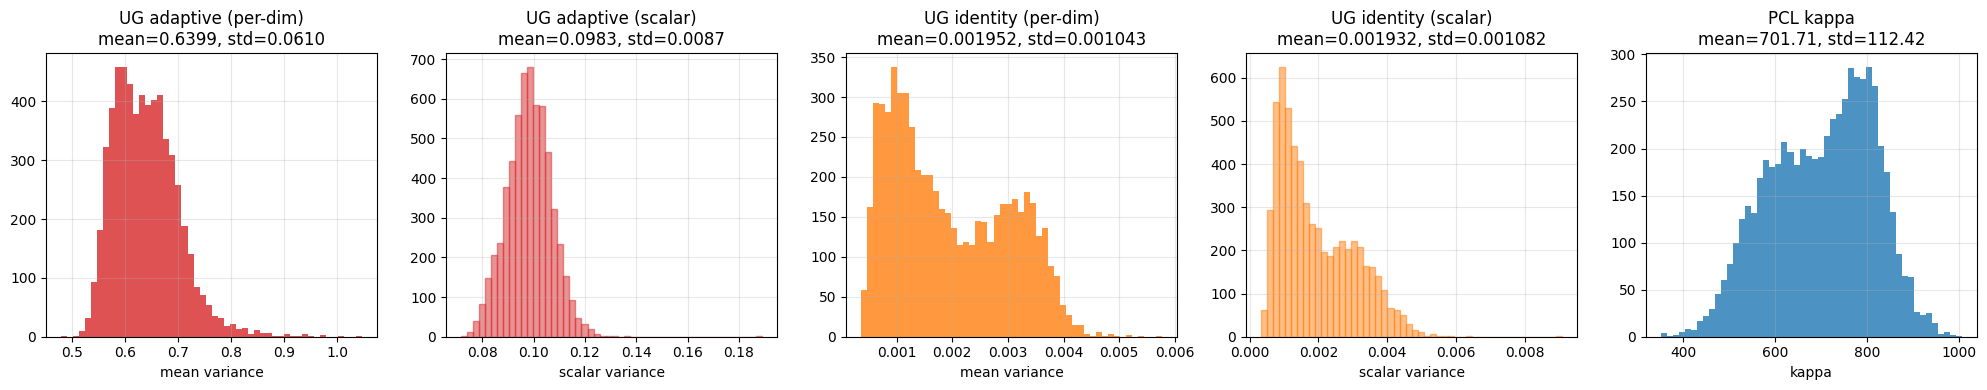

In [34]:
n_plots = 5 if model_pcl is not None else 4
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))

# Per-dim adaptive
mv = test_emb_ug_ad.variance.mean(axis=1)
axes[0].hist(mv, bins=50, color='tab:red', alpha=0.8)
axes[0].set_xlabel('mean variance')
axes[0].set_title(f'UG adaptive (per-dim)\nmean={mv.mean():.4f}, std={mv.std():.4f}')
axes[0].grid(True, alpha=0.3)

# Scalar adaptive
mv_s = test_emb_ug_ad_s.variance[:, 0]  # all dims identical
axes[1].hist(mv_s, bins=50, color='tab:red', alpha=0.5, edgecolor='tab:red')
axes[1].set_xlabel('scalar variance')
axes[1].set_title(f'UG adaptive (scalar)\nmean={mv_s.mean():.4f}, std={mv_s.std():.4f}')
axes[1].grid(True, alpha=0.3)

# Per-dim identity
mv2 = test_emb_ug_id.variance.mean(axis=1)
axes[2].hist(mv2, bins=50, color='tab:orange', alpha=0.8)
axes[2].set_xlabel('mean variance')
axes[2].set_title(f'UG identity (per-dim)\nmean={mv2.mean():.6f}, std={mv2.std():.6f}')
axes[2].grid(True, alpha=0.3)

# Scalar identity
mv2_s = test_emb_ug_id_s.variance[:, 0]
axes[3].hist(mv2_s, bins=50, color='tab:orange', alpha=0.5, edgecolor='tab:orange')
axes[3].set_xlabel('scalar variance')
axes[3].set_title(f'UG identity (scalar)\nmean={mv2_s.mean():.6f}, std={mv2_s.std():.6f}')
axes[3].grid(True, alpha=0.3)

# PCL kappa for reference
if model_pcl is not None:
    axes[4].hist(test_emb_pcl.kappa, bins=50, color='tab:blue', alpha=0.8)
    axes[4].set_xlabel('kappa')
    axes[4].set_title(f'PCL kappa\nmean={test_emb_pcl.kappa.mean():.2f}, '
                      f'std={test_emb_pcl.kappa.std():.2f}')
    axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation: Per-dim vs Scalar Uncertainty

Do the two uncertainty signals agree on which samples are uncertain?

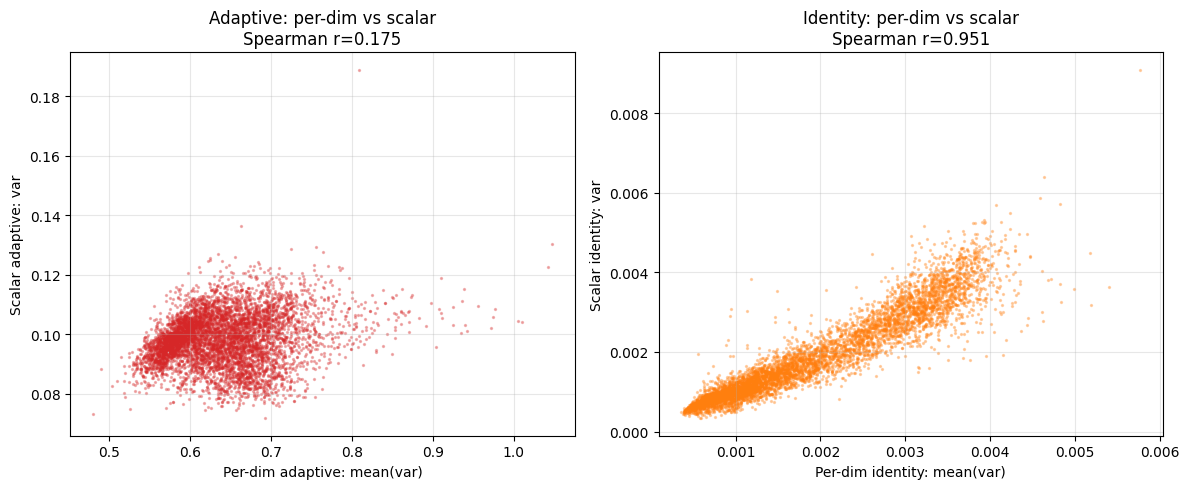

In [35]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Adaptive: per-dim mean var vs scalar var
x_ad = test_emb_ug_ad.variance.mean(axis=1)
y_ad = test_emb_ug_ad_s.variance[:, 0]
axes[0].scatter(x_ad, y_ad, s=2, alpha=0.3, c='tab:red')
axes[0].set_xlabel('Per-dim adaptive: mean(var)')
axes[0].set_ylabel('Scalar adaptive: var')
rho, pval = spearmanr(x_ad, y_ad)
axes[0].set_title(f'Adaptive: per-dim vs scalar\nSpearman r={rho:.3f}')
axes[0].grid(True, alpha=0.3)

# Identity: per-dim mean var vs scalar var
x_id = test_emb_ug_id.variance.mean(axis=1)
y_id = test_emb_ug_id_s.variance[:, 0]
axes[1].scatter(x_id, y_id, s=2, alpha=0.3, c='tab:orange')
axes[1].set_xlabel('Per-dim identity: mean(var)')
axes[1].set_ylabel('Scalar identity: var')
rho2, pval2 = spearmanr(x_id, y_id)
axes[1].set_title(f'Identity: per-dim vs scalar\nSpearman r={rho2:.3f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## t-SNE: Uncertainty Heatmaps

All UG models share the same mean network (copied from NonLinear), so they share
t-SNE coordinates. Bottom row shows uncertainty colored by log10(mean variance).

Computing t-SNE (shared mean embeddings)...
  Done: (6000, 2)


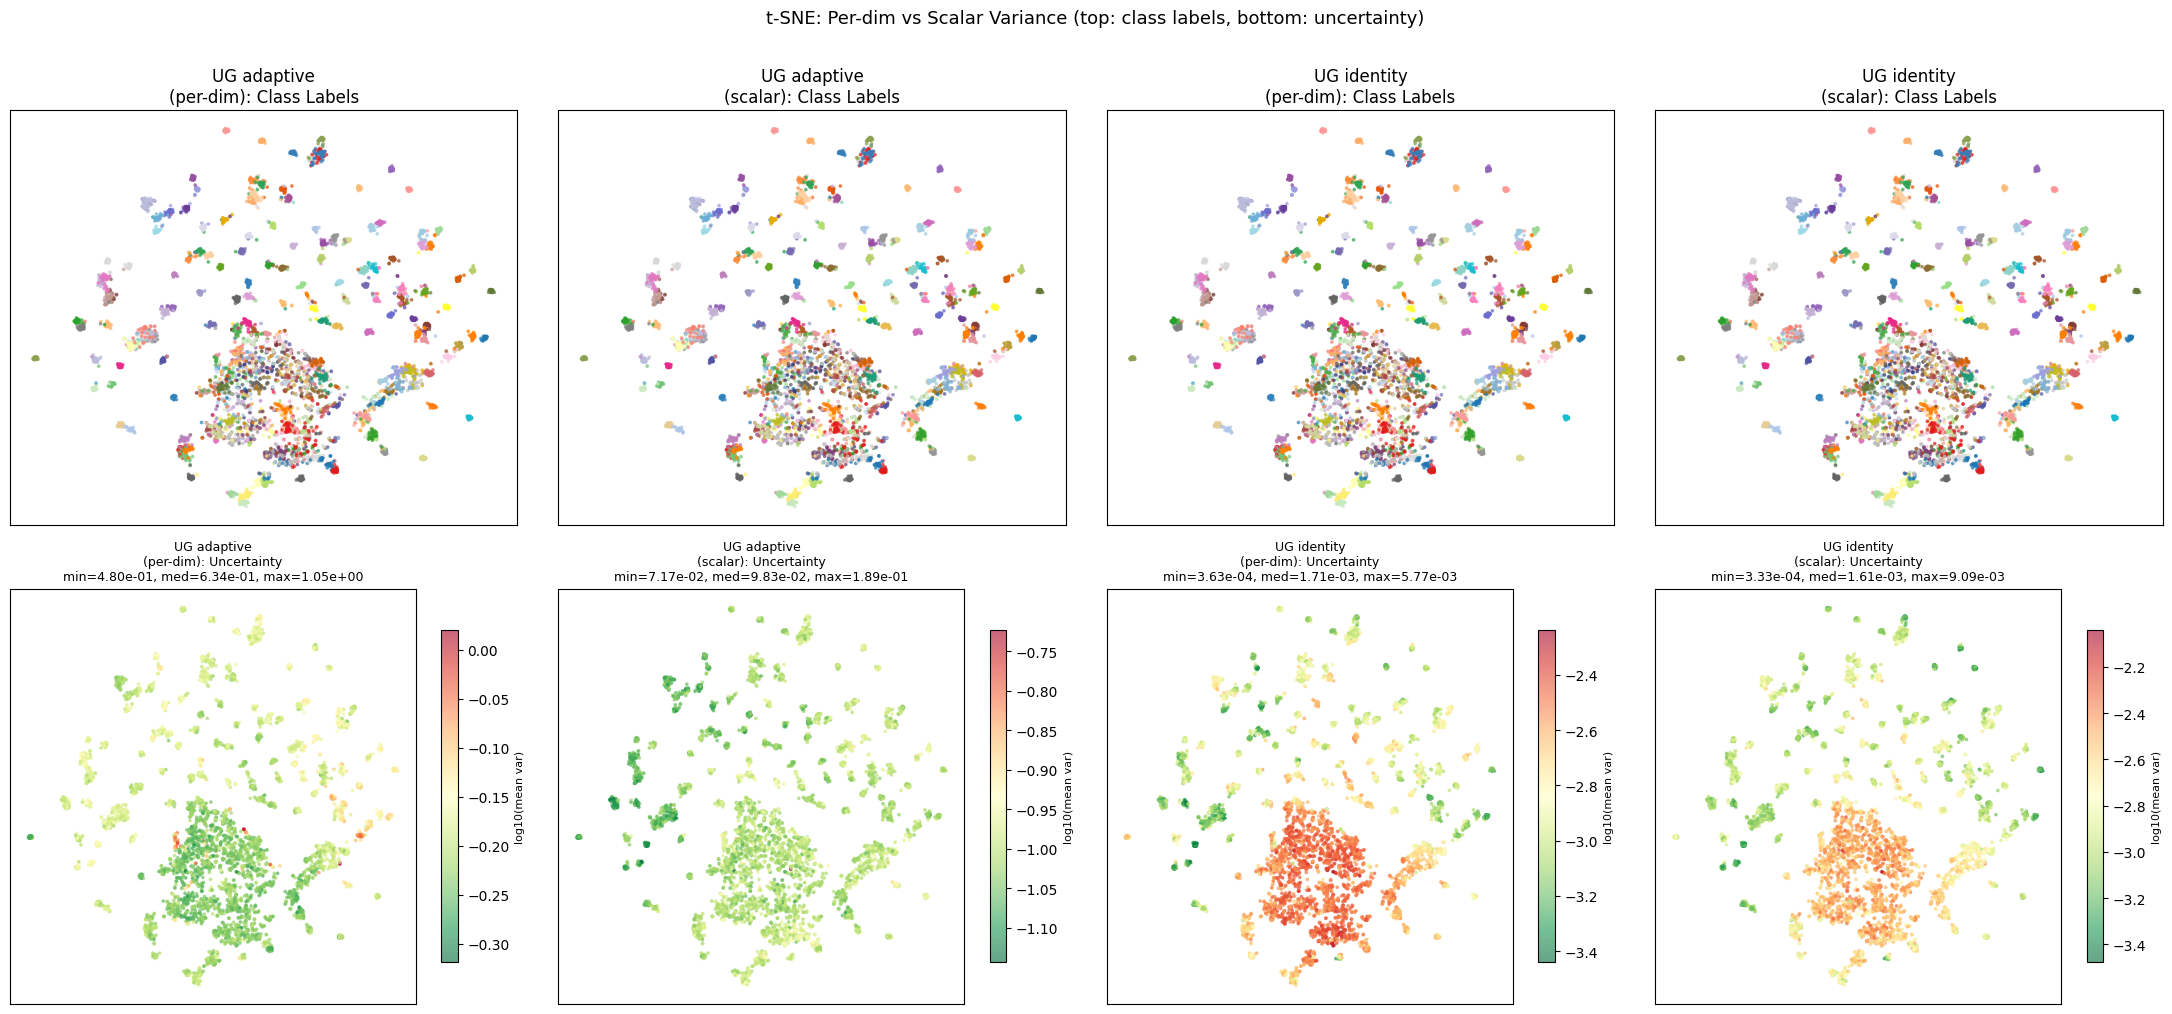

In [36]:
from sklearn.manifold import TSNE

print('Computing t-SNE (shared mean embeddings)...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(test_emb_nl.mean)
print(f'  Done: {coords.shape}')

# Species colors
point_size = 3
point_alpha = 0.6
true_unique = np.unique(test_labels)
n_true = len(true_unique)
base_colors = np.vstack([
    plt.cm.tab20(np.linspace(0, 1, 20)),
    plt.cm.tab20b(np.linspace(0, 1, 20)),
    plt.cm.tab20c(np.linspace(0, 1, 20)),
    plt.cm.Set1(np.linspace(0, 1, 9)),
    plt.cm.Set3(np.linspace(0, 1, 12)),
    plt.cm.Dark2(np.linspace(0, 1, 8)),
    plt.cm.Paired(np.linspace(0, 1, 12)),
])
species_colors = np.tile(base_colors, (max(1, n_true // len(base_colors) + 1), 1))[:n_true]
point_colors = np.array([species_colors[l] for l in test_labels])

models_vis = [
    ('UG adaptive\n(per-dim)', test_emb_ug_ad),
    ('UG adaptive\n(scalar)', test_emb_ug_ad_s),
    ('UG identity\n(per-dim)', test_emb_ug_id),
    ('UG identity\n(scalar)', test_emb_ug_id_s),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for col, (name, emb) in enumerate(models_vis):
    # Top: class labels
    axes[0, col].scatter(coords[:, 0], coords[:, 1], c=point_colors,
                         s=point_size, alpha=point_alpha, rasterized=True)
    axes[0, col].set_title(f'{name}: Class Labels')
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    # Bottom: uncertainty heatmap
    unc = np.log10(emb.variance.mean(axis=1) + 1e-12)
    sc = axes[1, col].scatter(coords[:, 0], coords[:, 1], c=unc,
                               cmap='RdYlGn_r', s=point_size, alpha=point_alpha, rasterized=True)
    cb = plt.colorbar(sc, ax=axes[1, col], shrink=0.8)
    cb.set_label('log10(mean var)', fontsize=8)
    mv = emb.variance.mean(axis=1)
    axes[1, col].set_title(f'{name}: Uncertainty\nmin={mv.min():.2e}, '
                           f'med={np.median(mv):.2e}, max={mv.max():.2e}', fontsize=9)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.suptitle('t-SNE: Per-dim vs Scalar Variance (top: class labels, bottom: uncertainty)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()